# Predict environmental stress using NDVI, soil moisture, temperature anomaly, and biome.



#### NDVI Index: vegetation health, from 0.00 to 1.00
### Soil Moisture %: available water in soil
### Temperature Anomaly C: how much hotter or cooler conditions are than normal
### Biome / Region: shown as a dropdown, though it is currently not used in the calculation

# Run Classification 

# So the model treats these as stress signals:--score increases when
## - lower NDVI = more vegetation stress
## - lower soil moisture = more water stress
## - higher temperature anomaly = more heat stress

# Stress increases when:
- NDVI is low
- soil moisture is low
- temperature anomaly is high
- rainfall is low
- humidity is low
- wind speed is high

# classifies the result:
## - score above 70 = High Water Stress
## - score above 45 = Moderate Stress
## - otherwise = Vegetation Healthy


In [23]:
# ============================================
# ENVIRONMENTAL STRESS PREDICTION NOTEBOOK
# USING REAL CSV DATASET
# ============================================

#NDVI Index: vegetation health, from 0.00 to 1.00
#Soil Moisture %: available water in soil
#Temperature Anomaly C: how much hotter or cooler conditions are than normal
#Biome / Region: shown as a dropdown, though it is currently not used in the calculation

# Run Classification 

#So the model treats these as stress signals:--score increases when
#- lower NDVI = more vegetation stress
#- lower soil moisture = more water stress
#- higher temperature anomaly = more heat stress



#classifies the result:
#- score above 70 = High Water Stress
# - score above 45 = Moderate Stress
#- otherwise = Vegetation Healthy

# =========================
# 1. INSTALL LIBRARIES
# =========================
!pip install pandas scikit-learn joblib matplotlib seaborn

# =========================
# 2. IMPORT LIBRARIES
# =========================
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder


[notice] A new release of pip is available: 26.0.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [25]:
# =========================
# 3. LOAD DATASET
# =========================
df = pd.read_csv("environmental_stress_data.csv")

# View first rows
df.head()

,ndvi,soil_moisture,temp_anomaly,rainfall_mm,humidity,wind_speed,biome,stress_label
0,0.254,51.5,2.6,0.0,23.8,18.9,Semi-arid savanna,HIGH WATER STRESS
1,0.453,44.7,0.7,52.6,59.3,16.4,Mediterranean shrubland,MODERATE STRESS
2,0.811,60.8,1.1,59.2,86.8,8.8,Tropical rainforest,VEGETATION HEALTHY
3,0.472,34.1,2.6,31.9,44.9,13.9,Mediterranean shrubland,MODERATE STRESS
4,0.800,77.4,1.1,146.0,73.9,7.0,Tropical rainforest,VEGETATION HEALTHY


In [6]:
# =========================
# 4. DATASET INFORMATION
# =========================
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nDataset Info:")
df.info()

print("\nMissing Values:")
print(df.isnull().sum())


Dataset Shape: (800, 8)

Column Names:
Index(['ndvi', 'soil_moisture', 'temp_anomaly', 'rainfall_mm', 'humidity',
       'wind_speed', 'biome', 'stress_label'],
      dtype='object')

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 800 entries, 0 to 799
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ndvi           800 non-null    float64
 1   soil_moisture  800 non-null    float64
 2   temp_anomaly   800 non-null    float64
 3   rainfall_mm    800 non-null    float64
 4   humidity       800 non-null    float64
 5   wind_speed     800 non-null    float64
 6   biome          800 non-null    object 
 7   stress_label   800 non-null    object 
dtypes: float64(6), object(2)
memory usage: 50.1+ KB

Missing Values:
ndvi             0
soil_moisture    0
temp_anomaly     0
rainfall_mm      0
humidity         0
wind_speed       0
biome            0
stress_label     0
dtype: int64


stress_label
VEGETATION HEALTHY    395
MODERATE STRESS       354
HIGH WATER STRESS      51
Name: count, dtype: int64


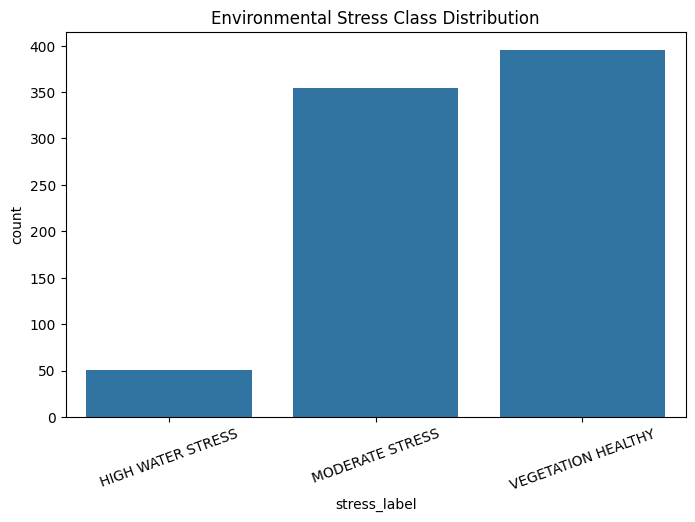

In [7]:
# =========================
# 5. TARGET CLASS DISTRIBUTION
# =========================
print(df["stress_label"].value_counts())

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="stress_label")
plt.xticks(rotation=20)
plt.title("Environmental Stress Class Distribution")
plt.show()


In [8]:
# =========================
# 6. DEFINE FEATURES & TARGET
# =========================
FEATURES = [
    "ndvi",
    "soil_moisture",
    "temp_anomaly",
    "rainfall_mm",
    "humidity",
    "wind_speed",
    "biome"
]

TARGET = "stress_label"

X = df[FEATURES]
y = df[TARGET]


In [9]:
# =========================
# 7. TRAIN TEST SPLIT
# =========================
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    random_state=42,
    stratify=y
)

print("Training Samples:", X_train.shape[0])
print("Testing Samples:", X_test.shape[0])

# =========================
# 8. PREPROCESSING
# =========================
numeric_features = [
    "ndvi",
    "soil_moisture",
    "temp_anomaly",
    "rainfall_mm",
    "humidity",
    "wind_speed"
]

categorical_features = ["biome"]

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("numeric", "passthrough", numeric_features)
    ]
)


Training Samples: 600
Testing Samples: 200


In [10]:
# =========================
# 9. BUILD RANDOM FOREST MODEL
# =========================
classifier = RandomForestClassifier(
    n_estimators=250,
    random_state=42,
    class_weight="balanced"
)

model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", classifier)
    ]
)


In [12]:
# =========================
# 10. TRAIN MODEL
# =========================
model.fit(X_train, y_train)

print("Model training completed successfully.")

Model training completed successfully.


In [13]:
# =========================
# 11. MODEL PREDICTIONS
# =========================
predictions = model.predict(X_test)


In [14]:
# =========================
# 12. MODEL EVALUATION
# =========================
accuracy = accuracy_score(y_test, predictions)

print("Accuracy Score:", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, predictions))

Accuracy Score: 0.925

Classification Report:

                    precision    recall  f1-score   support

 HIGH WATER STRESS       1.00      0.69      0.82        13
   MODERATE STRESS       0.91      0.92      0.92        88
VEGETATION HEALTHY       0.93      0.96      0.95        99

          accuracy                           0.93       200
         macro avg       0.95      0.86      0.89       200
      weighted avg       0.93      0.93      0.92       200



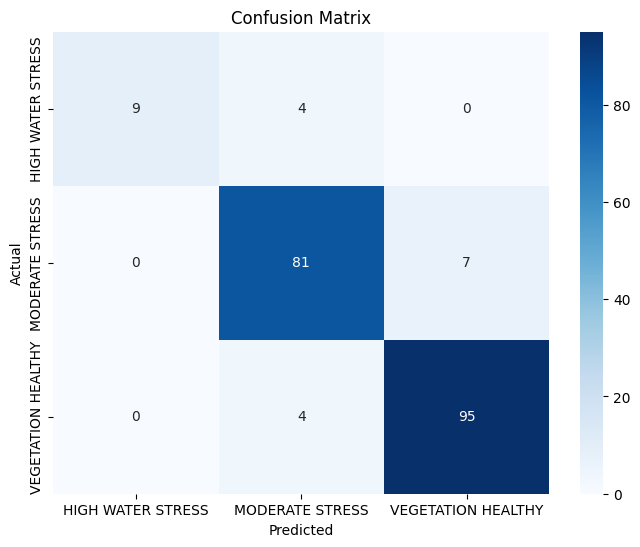

In [15]:
# =========================
# 13. CONFUSION MATRIX
# =========================
cm = confusion_matrix(y_test, predictions)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=model.classes_,
    yticklabels=model.classes_
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

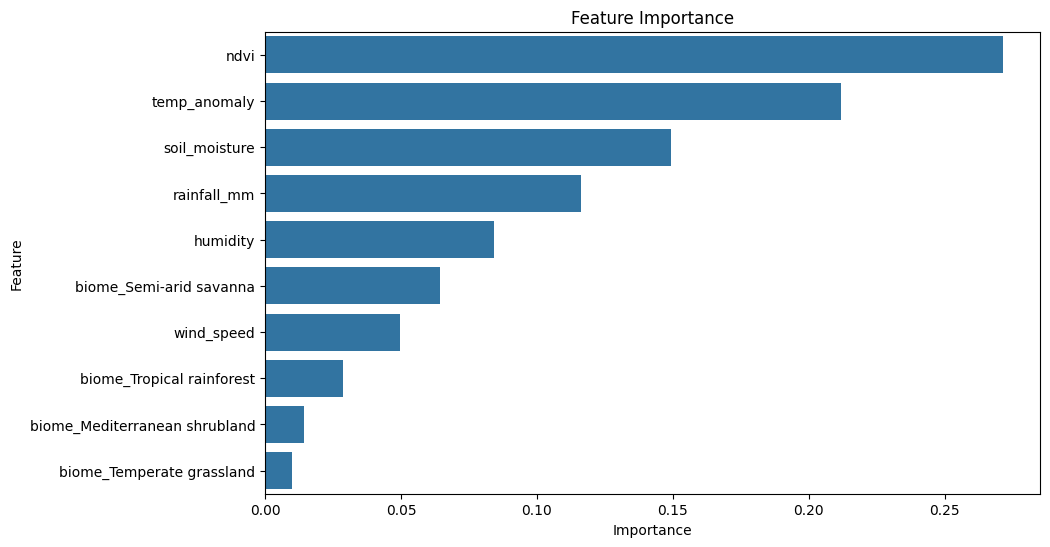

In [16]:
# =========================
# 14. FEATURE IMPORTANCE
# =========================
feature_names = (
    list(
        model.named_steps["preprocessor"]
        .named_transformers_["categorical"]
        .get_feature_names_out(["biome"])
    )
    + numeric_features
)

importances = model.named_steps["classifier"].feature_importances_

importance_df = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=importance_df, x="Importance", y="Feature")
plt.title("Feature Importance")
plt.show()


In [17]:
# =========================
# 15. SAVE TRAINED MODEL
# =========================
joblib.dump(model, "environmental_stress_model.joblib")
print("Model saved successfully.")

# =========================
# 16. LOAD MODEL
# =========================
loaded_model = joblib.load("environmental_stress_model.joblib")


Model saved successfully.


In [18]:
# =========================
# 17. SAMPLE PREDICTION
# =========================
sample = pd.DataFrame([
    {
        "ndvi": 0.25,
        "soil_moisture": 20,
        "temp_anomaly": 2.5,
        "rainfall_mm": 15,
        "humidity": 30,
        "wind_speed": 28,
        "biome": "Semi-arid savanna"
    }
])

prediction = loaded_model.predict(sample)[0]
probabilities = loaded_model.predict_proba(sample)[0]
confidence = probabilities.max() * 100

print("Prediction:", prediction)
print("Confidence:", round(confidence, 2), "%")


Prediction: HIGH WATER STRESS
Confidence: 91.2 %


In [19]:
# =========================
# 18. CUSTOM PREDICTION FUNCTION
# =========================
def predict_environmental_stress(
    ndvi,
    soil_moisture,
    temp_anomaly,
    rainfall_mm,
    humidity,
    wind_speed,
    biome
):
    sample = pd.DataFrame([{
        "ndvi": ndvi,
        "soil_moisture": soil_moisture,
        "temp_anomaly": temp_anomaly,
        "rainfall_mm": rainfall_mm,
        "humidity": humidity,
        "wind_speed": wind_speed,
        "biome": biome
    }])

    prediction = loaded_model.predict(sample)[0]
    probabilities = loaded_model.predict_proba(sample)[0]
    confidence = probabilities.max() * 100

    print("Predicted Class:", prediction)
    print("Confidence:", round(confidence, 2), "%")

# Example
predict_environmental_stress(
    ndvi=0.18,
    soil_moisture=12,
    temp_anomaly=3.2,
    rainfall_mm=8,
    humidity=22,
    wind_speed=34,
    biome="Semi-arid savanna"
)

Predicted Class: HIGH WATER STRESS
Confidence: 90.0 %
